# K-Nearest Neighbors
### Definition
K-Nearest Neighbors is a supervised machine learning regression algorithm that looks at nearby training data to predict the target value of the next point.

This algorithm uses a provided distance function in order to predict the value of the next point.

1. For the provided datapoint, calculate its distance between every training datapoint.
2. Then, sort the datapoints by distances, and store the $k$ closest datapoints to the provided point.
3. Predict the target value of the provided datapoint by averaging the target values for the $k$ closest datapoints.

## Imports

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

import struct

sns.set_theme()

## Data Preprocessing
We will load in the AutoMPG data that we created in the preprocessing step:

In [3]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/AutoMPG-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
train_X

array([[ 1.49630792,  1.08923273,  0.66835485, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.50162428,  1.58460471, ...,  0.77258661,
        -0.46138749, -0.49701778],
       [ 1.49630792,  1.19472824,  1.1919262 , ...,  0.77258661,
        -0.46138749, -0.49701778],
       ...,
       [-0.85524411, -0.69460048,  0.27567634, ..., -1.29110112,
         2.16192996, -0.49701778],
       [ 0.3205319 , -0.29179943,  0.74689055, ..., -1.29110112,
         2.16192996, -0.49701778],
       [-0.85524411, -1.00149651, -0.87618062, ..., -1.29110112,
         2.16192996, -0.49701778]], shape=(279, 8))

## Implementation

In [4]:
def euclidean_distance(p, q):
    return np.sqrt((p - q) @ (p - q))

In [5]:
def MSE(predictions, test_y):
    cost = 0.0
    for i in range(len(predictions)):
        cost += (predictions[i] - test_y[i])**2
    cost /= 2.0*len(predictions)
    return cost

In [15]:
def get_k_nearest_neighbors(dist_func, train_X, train_y, point, k):
    # build distance dictionary
    distances = []
    for i in range(np.shape(train_X)[0]):
        dist = dist_func(train_X[i], point)
        distances.append([train_X[i], train_y[i], dist])
    return sorted(distances, key=lambda x: x[-1])[:k]

def predict_k_nearest_neighbors(dist_func, train_x, train_y, point, k):
    nearest_neighbors = get_k_nearest_neighbors(dist_func, train_x, train_y, point, k)
    prediction = 0.0
    for i in range(k):
        neighbor = nearest_neighbors[i]
        neighbor_prediction = neighbor[1]
        prediction += neighbor_prediction / k
    return prediction

def test_k_nearest_neighbors(dist_func, train_X, train_y, test_X, test_y, k):
    # return average MSE
    n = test_X.shape[0]
    predictions = [predict_k_nearest_neighbors(dist_func, train_X, train_y, test_X[i, :], k) for i in range(n)]
    return MSE(predictions, test_y)

## Data Analysis

In [16]:
print("  k | MSE of KNN with Euclidean distance")
print("----|----------------------------------------------------------------")
for k in range(1, 31, 2):
    pred_rate = test_k_nearest_neighbors(euclidean_distance, train_X, train_y, test_X, test_y, k)
    print(f" {k:2d} | {pred_rate:1.3f}")

  k | MSE of KNN with Euclidean distance
----|----------------------------------------------------------------
  1 | 0.436
  3 | 0.390
  5 | 0.375
  7 | 0.376
  9 | 0.376
 11 | 0.381
 13 | 0.385
 15 | 0.387
 17 | 0.394
 19 | 0.399
 21 | 0.410
 23 | 0.417
 25 | 0.428
 27 | 0.433
 29 | 0.443


Here, we can see that the MSE is smallest when considering the average of around 10 of the nearest neighbors.

Now, visualize the plots of the KNN regressors:

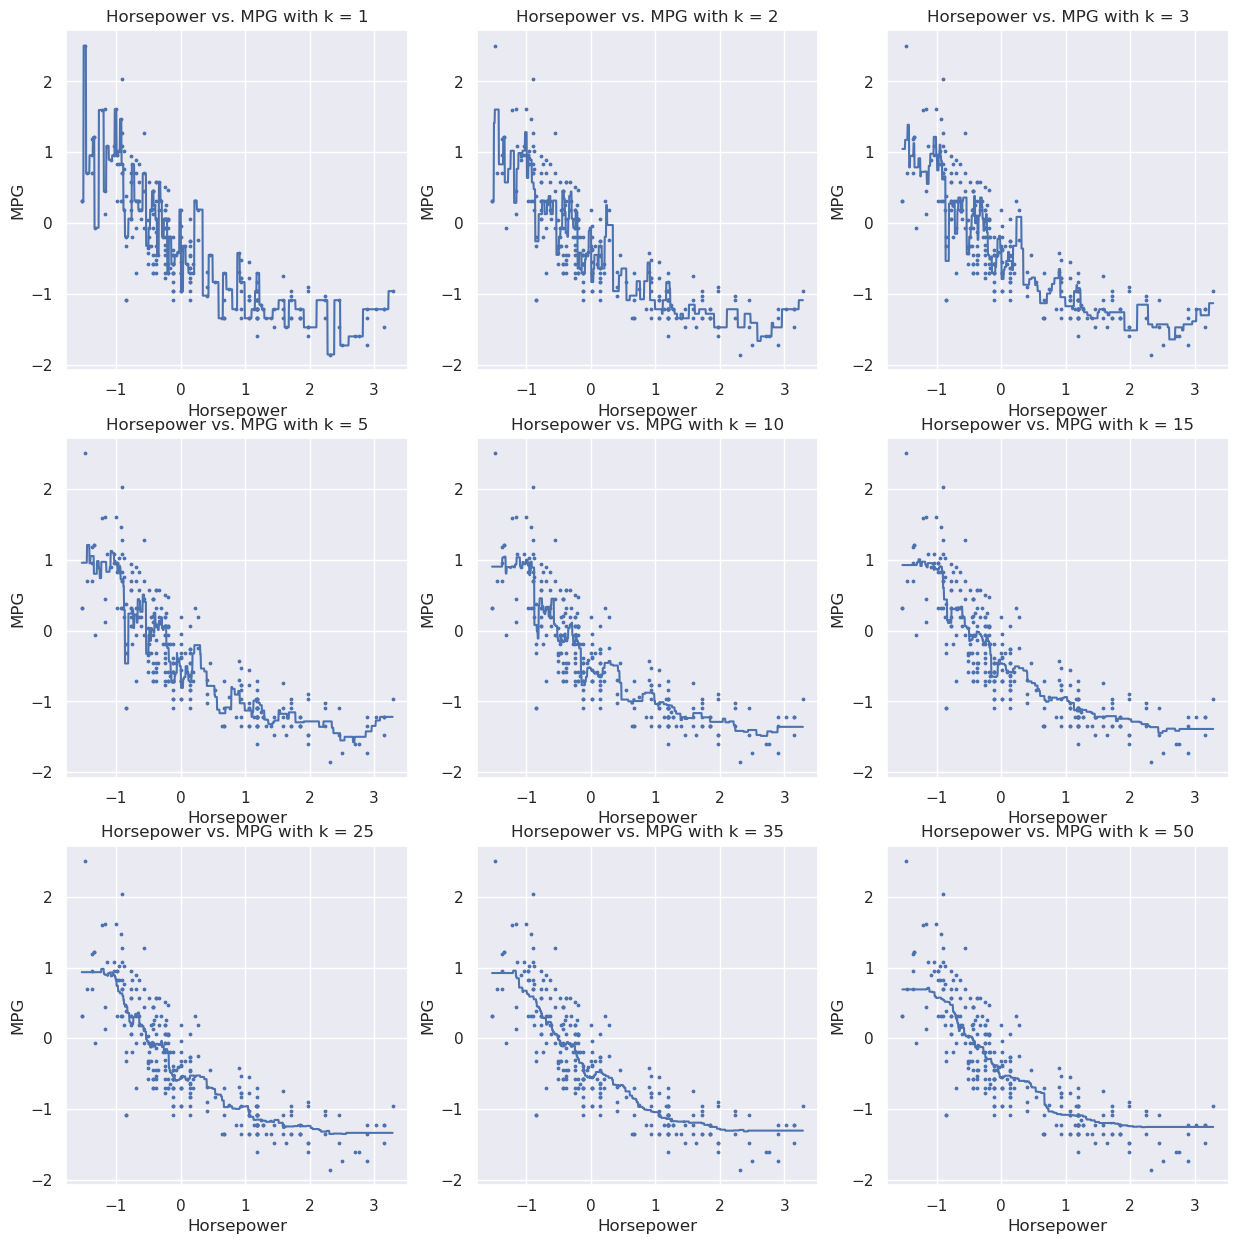

In [20]:
fig, axs = plt.subplots(3, 3, figsize = (15, 15))
t = np.linspace(min(train_X[:, 2]), max(train_X[:, 2]), 1000)[:, np.newaxis]

k_vals = [1, 2, 3, 5, 10, 15, 25, 35, 50]
for (j, k) in enumerate(k_vals):
    i1, i2 = j // 3, j % 3
    predictions = [predict_k_nearest_neighbors(euclidean_distance, train_X[:, 2], train_y, t_i, k) for t_i in t]
    axs[i1, i2].plot(t, predictions)
    axs[i1, i2].set_xlabel("Horsepower")
    axs[i1, i2].set_ylabel("MPG")
    axs[i1, i2].set_title(f"Horsepower vs. MPG with k = {k}")
    axs[i1, i2].scatter(train_X[:, 2], train_y[:], s = 3)

As we can see, the KNN regression algorithm, as k increases, becomes closer to a line minimizing the distance between as many points as possible. It also oscillates less and less.